Imports:

In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import Binarizer

from torch.utils.data import random_split

from torchvision import datasets
from torchvision.transforms import ToTensor

from pathlib import Path

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\torchvision\io\image.py:11: UserWarning: Failed to load image Python extension: Could not find module 'A:\ProgrammingStuff\Other\Anaconda3\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warn(f"Failed to load image Python extension: {e}")


Function Definitions:

In [2]:
def formatImage(filepath):
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_LINEAR)
    img_resized = cv2.bitwise_not(img_resized)
    img_resized = np.copy(img_resized).reshape(1, 784)
    img_final = torch.tensor(img_resized, dtype=torch.float32)
    return img_final

def visualizeEmnist():
    figure = plt.figure(figsize=(10, 8))
    cols, rows = 5, 5
    for i in range(1, cols * rows + 1):
        sample_idx = torch.randint(len(train_data), size=(1,)).item()
        img, label = train_data[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(label)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap="gray")
    plt.show()
    
def visualizeMnist():
    figure = plt.figure(figsize=(10, 8))
    cols, rows = 5, 5
    for i in range(1, cols * rows + 1):
        sample_idx = torch.randint(len(train_digits), size=(1,)).item()
        img, label = train_digits[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(label)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap="gray")
    plt.show()
    
def visualizeCustom():
    figure = plt.figure(figsize=(10, 8))
    cols, rows = 5, 5
    for i in range(1, cols * rows + 1):
        img = customImages[i-1]
        label = customLabels[i-1]
    
        img = img.reshape(28, 28)
        figure.add_subplot(rows, cols, i)
        plt.title(label.item())
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap="gray")
    plt.show()

EMNIST Dataset Initialization:

In [3]:
train_data = datasets.EMNIST(
    root = 'data',
    split = 'balanced',
    train = True,                         
    transform = ToTensor(), 
    download = True,            
)
test_data = datasets.EMNIST(
    root = 'data', 
    split = 'balanced',
    train = False, 
    transform = ToTensor()
)

train_data, valid_data = random_split(train_data,[90240,22560])

train_digits = datasets.MNIST(root='data', download=True, train=True, transform=ToTensor())
test_digits = datasets.MNIST(root='data', download=True, train=False, transform=ToTensor())
train_digits, valid_digits = random_split(train_digits,[50000, 10000])

loaders = {
    'train' : torch.utils.data.DataLoader(train_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
    
    'test'  : torch.utils.data.DataLoader(test_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
}

60000


Custom Dataset Initialization:

In [4]:
#Get Image Directory
cwd = Path.cwd()
imgdir = os.path.join(cwd, 'img')

customImages = torch.zeros(len(os.listdir(imgdir)), 784)
customLabels = torch.zeros(len(os.listdir(imgdir)))

counter = 0

for filename in os.listdir(imgdir):
    filepath = os.path.join(imgdir, filename)
    
    img_final = formatImage(filepath)
    img_label = torch.tensor(int(os.path.splitext(filename)[0]), dtype=torch.int)
    
    customImages[counter] = img_final
    customLabels[counter] = img_label
    counter += 1

Visualize Datasets:

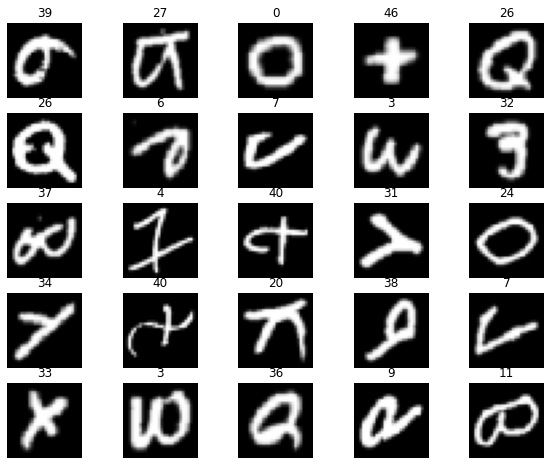

In [5]:
visualizeEmnist()

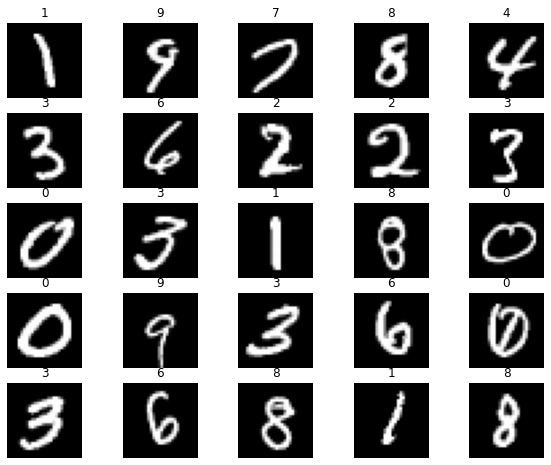

In [6]:
visualizeMnist()

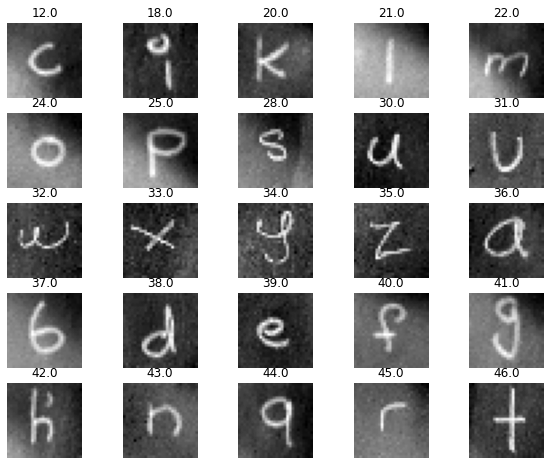

In [7]:
visualizeCustom()

In [8]:
# Normalize Images
sample = next(iter(loaders['test']))
imgs, lbls = sample
imgs_t = imgs.clone().detach()
imgs_t = np.copy(imgs_t).reshape(-1, 784)

transformer = Binarizer().fit(imgs_t)

customImages = transformer.transform(customImages)
customImages = torch.tensor(customImages)

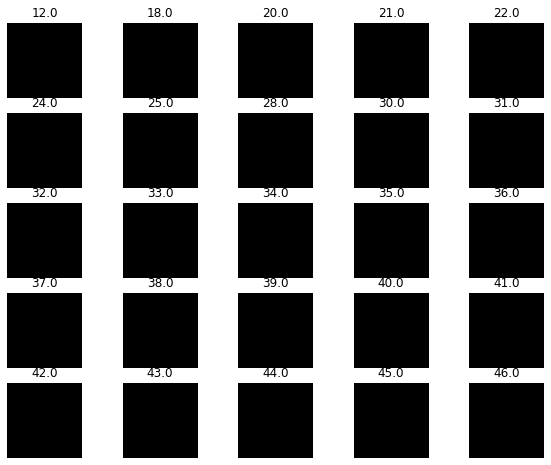

In [9]:
visualizeCustom()